RiskProof AI: Naive Bayes Classification on Fraud Oracle

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import joblib

%matplotlib inline

## 1. Load Dataset

In [7]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [8]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('Missing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0
Duplicates after: 0
Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)


## 3. Prepare Features

Input shape after encoding: (15420, 122)
Target distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64


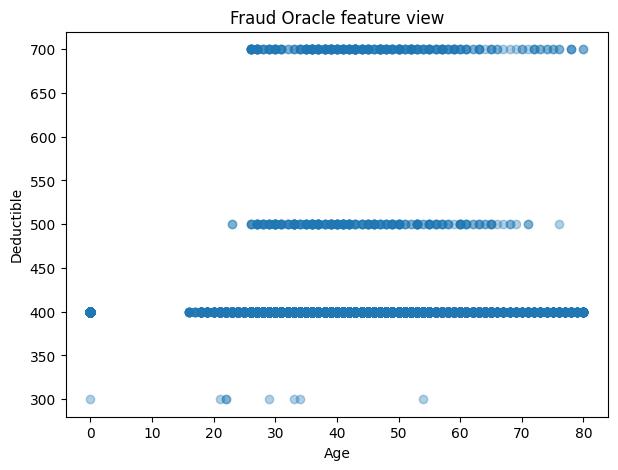

In [9]:
target = df['FraudFound_P']
feature_source = df.drop(['FraudFound_P', 'PolicyNumber', 'RepNumber'], axis=1)

categorical_cols = feature_source.select_dtypes(include=['object', 'string']).columns
inputs = pd.get_dummies(feature_source, columns=categorical_cols, drop_first=True)

print('Input shape after encoding:', inputs.shape)
print('Target distribution:')
print(target.value_counts())

# A quick visual check on two numeric features similar to the reference style
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Deductible'], alpha=0.35)
plt.xlabel('Age')
plt.ylabel('Deductible')
plt.title('Fraud Oracle feature view')
plt.show()

## 4. Split Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs,
    target,
    test_size=0.3,
    random_state=42,
    stratify=target
)

print('Length of X_train:', len(X_train))
print('Length of X_test:', len(X_test))
print('Length of inputs:', len(inputs))

Length of X_train: 10794
Length of X_test: 4626
Length of inputs: 15420


## 5. Train Naive Bayes With Different Parameters

In [11]:
base_model = GaussianNB()
base_model.fit(X_train, y_train)
base_accuracy = base_model.score(X_test, y_test)
print('Base Naive Bayes accuracy:', base_accuracy)

best_model = None
best_accuracy = -1
best_smoothing = None

for smoothing in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]:
    model = GaussianNB(var_smoothing=smoothing)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f'var_smoothing={smoothing}, accuracy={score}')
    if score > best_accuracy:
        best_accuracy = score
        best_model = model
        best_smoothing = smoothing

print('Best var_smoothing:', best_smoothing)
print('Best accuracy:', best_accuracy)

cv_scores = cross_val_score(GaussianNB(var_smoothing=best_smoothing), X_train, y_train, cv=5)
print('Cross validation scores:', cv_scores)
print('Mean CV score:', cv_scores.mean())

Base Naive Bayes accuracy: 0.37332468655425854
var_smoothing=1e-09, accuracy=0.37332468655425854
var_smoothing=1e-08, accuracy=0.49546044098573283
var_smoothing=1e-07, accuracy=0.6655858192823173
var_smoothing=1e-06, accuracy=0.7734543882403805
var_smoothing=1e-05, accuracy=0.7993947254647644
Best var_smoothing: 1e-05
Best accuracy: 0.7993947254647644
Cross validation scores: [0.80592867 0.80407596 0.81009727 0.78925428 0.80305839]
Mean CV score: 0.8024829141627972


### Visualizing Parameter Impact
To better understand how the `var_smoothing` parameter influences the model performance, we can plot the accuracy scores obtained during the tuning process.

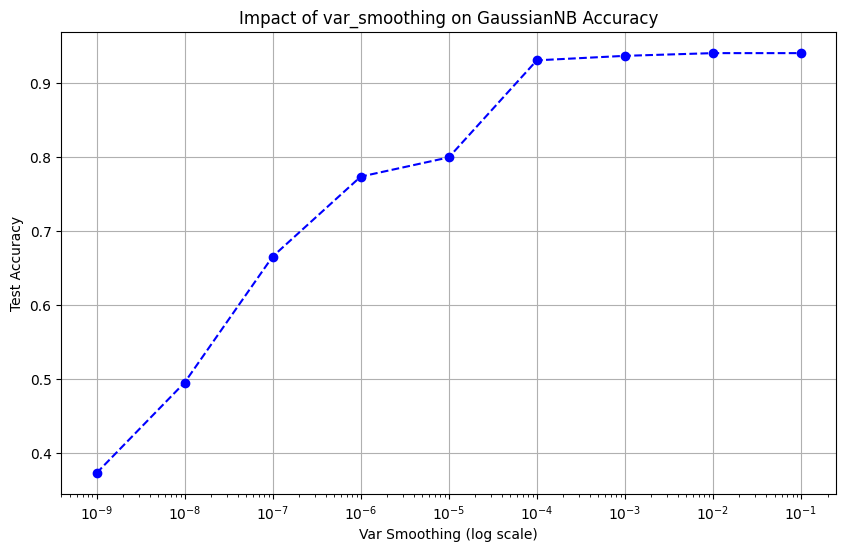

In [15]:
smooth_params = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]
accuracies = []

for s in smooth_params:
    m = GaussianNB(var_smoothing=s)
    m.fit(X_train, y_train)
    accuracies.append(m.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(smooth_params, accuracies, marker='o', linestyle='--', color='b')
plt.xscale('log')
plt.xlabel('Var Smoothing (log scale)')
plt.ylabel('Test Accuracy')
plt.title('Impact of var_smoothing on GaussianNB Accuracy')
plt.grid(True)
plt.show()

## 6. Predict and Evaluate

In [13]:
y_pred = best_model.predict(X_test)
print('Sample predictions:', y_pred[:10])

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

sample_probs = best_model.predict_proba(X_test[:10])
print('Sample probabilities:')
print(np.round(sample_probs, 4))

risk_label_map = {0: 'Low-risk claim', 1: 'High-risk claim'}
predicted_labels = [risk_label_map[int(label)] for label in y_pred[:10]]
print('Sample risk labels:', predicted_labels)

Sample predictions: [0 0 0 1 0 1 0 1 0 0]
Confusion matrix:
 [[3572  777]
 [ 151  126]]
Accuracy: 0.7993947254647644

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.82      0.89      4349
           1       0.14      0.45      0.21       277

    accuracy                           0.80      4626
   macro avg       0.55      0.64      0.55      4626
weighted avg       0.91      0.80      0.84      4626

Sample probabilities:
[[1.000e+00 0.000e+00]
 [1.000e+00 0.000e+00]
 [6.406e-01 3.594e-01]
 [2.000e-04 9.998e-01]
 [8.819e-01 1.181e-01]
 [7.530e-02 9.247e-01]
 [1.000e+00 0.000e+00]
 [3.245e-01 6.755e-01]
 [1.000e+00 0.000e+00]
 [9.993e-01 7.000e-04]]
Sample risk labels: ['Low-risk claim', 'Low-risk claim', 'Low-risk claim', 'High-risk claim', 'Low-risk claim', 'High-risk claim', 'Low-risk claim', 'High-risk claim', 'Low-risk claim', 'Low-risk claim']


## 7. Save Model

In [14]:
model_bundle = {
    'model': best_model,
    'feature_columns': inputs.columns.tolist(),
    'best_var_smoothing': best_smoothing,
    'risk_label_map': {0: 'Low-risk claim', 1: 'High-risk claim'}
}

with open('riskproof_naive_bayes.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

joblib.dump(model_bundle, 'riskproof_naive_bayes.joblib')
print('Saved model files: riskproof_naive_bayes.pkl and riskproof_naive_bayes.joblib')

Saved model files: riskproof_naive_bayes.pkl and riskproof_naive_bayes.joblib
